In [1]:
%reload_ext autoreload
%autoreload 2

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

In [3]:
import jax
import jax.numpy as jnp
from jax.experimental.pallas.ops.gpu.attention import mha

jax.devices()

[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2)]

In [4]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [5]:
import numpy as np
import scipy.ndimage as ndi

NUM_PIXELS = 28 * 28
NUM_CLASSES = 256

def img_aug(x):
    xs_batch = x["image"]

    # Accept (B,H,W,1) by squeezing the channel
    if xs_batch.ndim == 4 and xs_batch.shape[-1] == 1:
        xs_batch = xs_batch[..., 0]

    xs_batch = xs_batch.astype(np.float32) / 255.0

    # --- small rotation for the whole batch ---
    angle = np.random.uniform(-4.0, 4.0)  # degrees
    xs_batch = ndi.rotate(
        xs_batch,
        angle=angle,
        axes=(1, 2),
        reshape=False,
        order=1,
        mode="constant",
        cval=0.0
    )

    # --- small translation for the whole batch ---
    ty = np.random.uniform(-2.0, 2.0)     # shift in y (pixels)
    tx = np.random.uniform(-2.0, 2.0)     # shift in x (pixels)
    # For a (B,H,W) array, give one shift per axis: (B, H, W) -> (0, ty, tx)
    xs_batch = ndi.shift(
        xs_batch,
        shift=(0.0, ty, tx),
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False  # only needed for order > 1
    )

    xs_batch = np.clip(xs_batch, 0.0, 1.0)
    xs_batch = np.rint(xs_batch * 255.0).astype(np.int32)

    return xs_batch.reshape(-1, NUM_PIXELS)


In [6]:
from probjax.nn.io_util import DataLoader

loader = DataLoader(dataset["train"],batch_size=256*3, num_prefetch_host=8, num_prefetch_device=2, shard=True, host_transforms=[img_aug], num_async_workers=1)

In [7]:
datastream = iter(loader)

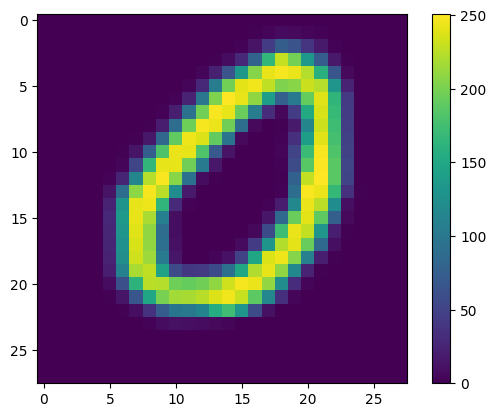

In [8]:
images = next(datastream)
plt.imshow(images[0,0].reshape(28,28))
plt.colorbar()

In [9]:
from probjax.nn import Transformer, LearnablePosEncode
from probjax.nn.layers.attention import flex_attention
from probjax.nn.pallas_kernels.attention_mask_bias import CausalMask

import optax

class Model(nnx.Module):

    num_heads: int = 8
    num_layers: int = 8
    dim: int
    widening_factor: int = 4
    attn_size: int = 32
    vocab_size: int = NUM_CLASSES

    def __init__(self, dim, rngs, dropout_rate=None):
        del dropout_rate
        self.embed = nnx.Embed(self.vocab_size, dim, rngs=rngs)
        self.pos_embed = LearnablePosEncode(dim, max_seq_len=NUM_PIXELS + 1, rngs=rngs)
        self.transformer = Transformer(
            dim,
            self.num_heads,
            self.num_heads,
            self.attn_size,
            attention_fn=flex_attention,
            widening_factor=self.widening_factor,
            rngs=rngs,
            dtype=jnp.bfloat16,
            precision="BF16_BF16_F32",
            preferred_element_type=jnp.float32,
        )
        self.output = nnx.Linear(dim, self.vocab_size, rngs=rngs, kernel_init=nnx.initializers.zeros)
        self.start_token = nnx.Param(jnp.zeros((1, dim)))

    def __call__(self, x, decode=False, deterministic=False):
        x = jnp.asarray(x, dtype=jnp.int32)
        x = self.embed(x)
        x = self.pos_embed(x)
        start_token = jnp.repeat(self.start_token.value[None, ...], x.shape[0], axis=0)
        x = jnp.concatenate([start_token, x], axis=1)
        mask = CausalMask()
        x = self.transformer(x, mask=mask, deterministic=deterministic, decode=decode)
        logits = self.output(x)
        return logits[..., :-1, :]

    def loss(self, params, x):
        nnx.update(self, params)
        logits = self(x)
        targets = jnp.asarray(x, dtype=jnp.int32)
        token_loss = optax.softmax_cross_entropy_with_integer_labels(logits, targets)
        token_loss = jnp.sum(token_loss, axis=-1)
        return jnp.mean(token_loss)

    def predict_logits(self, x, decode=False, deterministic=False):
        return self(x, decode=decode, deterministic=deterministic)


model = Model(512, rngs=nnx.Rngs(0))
params = nnx.state(model, nnx.Param)


In [10]:
# Visualize initial model denoising
x = next(datastream)

y = model.loss(params,x[0])
y

Array(4347.418, dtype=float32)

In [11]:
# def loss_fn(params, x, rng):
#     return model.loss_masked(params, x, rng)

# AR loss
def loss_fn(params, x, _):
    return model.loss(params, x)

In [14]:
from functools import partial
import optax


opt = optax.chain(optax.adaptive_grad_clip(5.), optax.radam(1e-4))
params_per_device = jax.tree_util.tree_map(
    lambda p: jnp.stack([p] * jax.local_device_count(), axis=0),
    params
)
opt_state = jax.vmap(opt.init)(params_per_device)

@partial(jax.pmap, axis_name='batch')
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    grads = jax.tree_util.tree_map(lambda x: jnp.nan_to_num(x), grads)

    # Average across all replicas on the 'batch' axis
    loss = jax.lax.pmean(loss, axis_name='batch')
    grads = jax.lax.pmean(grads, axis_name='batch')

    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    params = jax.tree_util.tree_map(lambda x: jnp.nan_to_num(x), params)

    return params, opt_state, loss

def train_step(params, opt_state, xs, rng):
    # Reshape xs to split across devices
    rng = jax.random.split(rng, jax.local_device_count())

    params, opt_state, losses = update(params, opt_state, xs, rng)
    return params, opt_state, jnp.mean(losses)


In [13]:
import pickle
with open("checkpoint.pkl", "rb") as f:
    checkpoint = pickle.load(f)

params = checkpoint["params"]
opt_state = checkpoint["opt_state"]

In [15]:
key = jax.random.key(4)

In [1]:
# Example training iteration
for i in range(10):
    l = 0.
    for j in range(1000):
        key, key_data, key_loss = jax.random.split(key, 3)
        xs = next(datastream)
        params_per_device, opt_state, loss = train_step(params_per_device, opt_state, xs, key_loss)
        l += loss
    print(l/1000)

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


NameError: name 'jax' is not defined

In [30]:
# convert device arrays to host numpy arrays and save
import pickle
checkpoint = {
	"params": jax.device_get(params),
	"opt_state": jax.device_get(opt_state),
}

with open("checkpoint.pkl", "wb") as f:
	pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved checkpoint to checkpoint.pkl")


Saved checkpoint to checkpoint.pkl


In [31]:
params = jax.tree_util.tree_map(lambda x: x[0], params_per_device)
nnx.update(model, params)

In [32]:
import math

nnx.update(model, params)

images_test = np.array(dataset["test"]["image"])

test_tokens = images_test.astype(np.int32).reshape(-1, 28*28)

BATCH_SIZE_EVAL = 512


def compute_bits_per_dim(tokens, batch_size=BATCH_SIZE_EVAL):
    total_nll = 0.0
    total_count = 0
    for start in range(0, tokens.shape[0], batch_size):
        batch = jnp.asarray(tokens[start:start + batch_size], dtype=jnp.int32)
        logits = model.predict_logits(batch, deterministic=True)
        loss = optax.softmax_cross_entropy_with_integer_labels(logits, batch)
        nll_per_sample = jnp.sum(loss, axis=-1)
        total_nll += float(jnp.sum(nll_per_sample))
        total_count += batch.shape[0]
    mean_nll = total_nll / total_count
    return mean_nll / (NUM_PIXELS * math.log(2.0))

bits_per_dim = compute_bits_per_dim(test_tokens)
print(f"Test bits per dim: {bits_per_dim:.4f}")


Test bits per dim: 1.1426


In [33]:
logits = model(x)


TypeError: Cannot concatenate arrays with different numbers of dimensions: got (3, 1, 512), (3, 256, 784, 512).

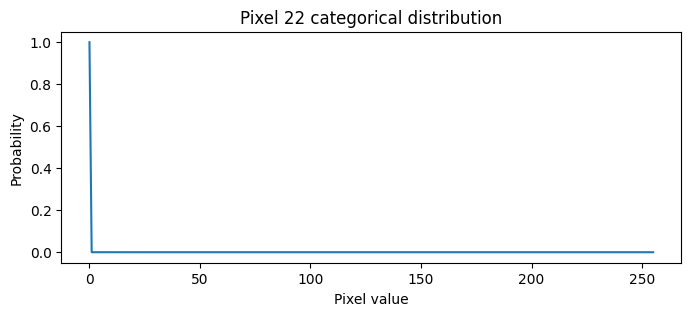

In [ ]:
pixel_idx = 22
pixel_logits = logits[0, pixel_idx]
pixel_probs = jax.nn.softmax(pixel_logits)

plt.figure(figsize=(8, 3))
plt.plot(jnp.arange(NUM_CLASSES), pixel_probs)
plt.title(f"Pixel {pixel_idx} categorical distribution")
plt.xlabel("Pixel value")
plt.ylabel("Probability")
plt.show()


In [38]:
T = xs.shape[-1]
d = jnp.sqrt(xs.shape[-1]).astype(jnp.int32)

def naive_autoregressive_decoding(key, T=T):
    init_tokens = jnp.zeros((1, T), dtype=jnp.int32)

    def scan_fn(carry, key_i):
        tokens, idx = carry
        logits = model.predict_logits(tokens)
        logits_i = logits[0, idx]
        sample = jax.random.categorical(key_i, logits_i).astype(jnp.int32)
        tokens = tokens.at[0, idx].set(sample)
        return (tokens, idx + 1), sample

    keys = jax.random.split(key, (T,))
    (tokens, _), _ = jax.lax.scan(scan_fn, (init_tokens, 0), keys)
    return tokens[0]


In [39]:
xs.shape

(3, 256, 784)

In [40]:
keys = jax.random.split(jax.random.key(0), (100,))

In [41]:
samples = jax.vmap(naive_autoregressive_decoding)(keys)

In [42]:
img = samples.reshape(10, 10, d, d).transpose(0, 2, 1, 3).reshape(10*d, 10*d)

In [43]:
img.max()

Array(255, dtype=int32)

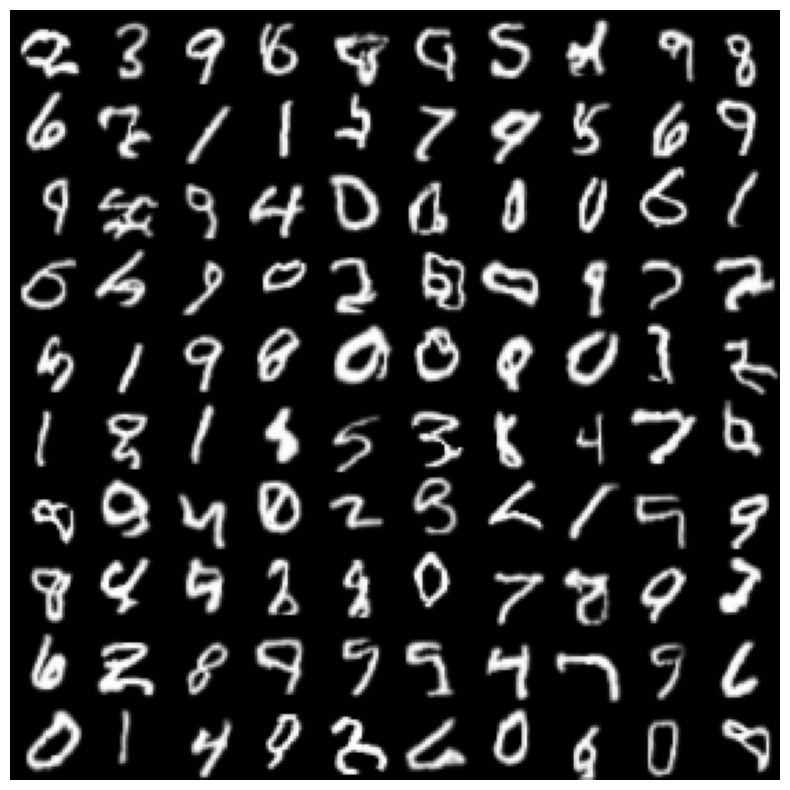

In [44]:
plt.figure(figsize=(10, 10))
plt.imshow(img/255, cmap="gray", vmin=0, vmax=1)
plt.axis('off')
plt.show()